# QQQ vs VOO Pairs Trading Analysis

**Author:** Nokijai  
**Date:** 2026-05-25

## Purpose

Evaluate whether **QQQ** (Nasdaq-100) and **VOO** (S&P 500) are suitable pair-trading candidates:

1. Check whether prices move in sync (correlation and charts)
2. Run an **ADF stationarity test** on the log-difference of the **QQQ/VOO ratio**
3. Run an **Engle–Granger cointegration test** (`coint`) on **Adj Close** price series
4. Summarize quantitative conclusions from the test results

> We use the **ratio** rather than a price **spread**, because QQQ has structurally outperformed VOO during the tech-led bull market.

## Data Loading

Download QQQ and VOO history, then compute **Adj Close** and the **QQQ/VOO ratio**.

In [48]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
import statsmodels.graphics.tsaplots as tsaplots

# Download QQQ & VOO (multi-index columns from yfinance)
data = yf.download(
    ["VOO", "QQQ"],
    start="2020-01-02",
    end="2026-05-01",
    auto_adjust=False,
)

adj = data["Adj Close"].copy()
qqq_adj = adj["QQQ"]
voo_adj = adj["VOO"]

# Ratio for relative-value / pairs view (QQQ per unit of VOO)
data["ratio"] = qqq_adj / voo_adj

out = adj.copy()
out["ratio"] = data["ratio"]
print(out.tail())

[*********************100%***********************]  2 of 2 completed

Ticker             QQQ         VOO     ratio
Date                                        
2026-04-24  663.880005  656.419983  1.011365
2026-04-27  664.229980  657.500000  1.010236
2026-04-28  657.549988  654.260010  1.005029
2026-04-29  661.570007  654.239990  1.011204
2026-04-30  667.739990  660.580017  1.010839


## Step 1: Correlation & Visualization

Plot **Adj Close** paths and the **ratio**, and compute Pearson correlation to see whether the two ETFs move together.

Adj Close correlation matrix:
Ticker       QQQ       VOO
Ticker                    
QQQ     1.000000  0.992326
VOO     0.992326  1.000000

QQQ vs VOO correlation: 0.9923


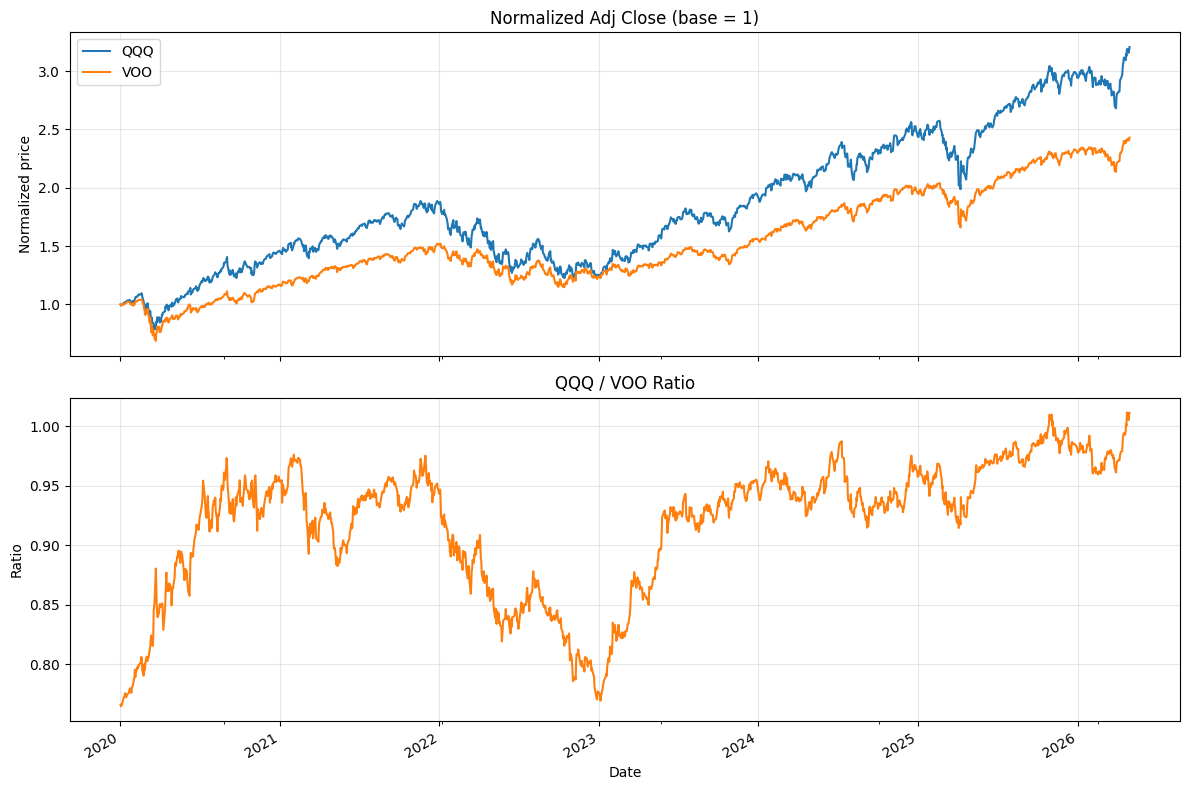

In [49]:
# Pearson correlation on adj close (levels move together?)
corr_matrix = adj.corr()
print("Adj Close correlation matrix:")
print(corr_matrix)
print(f"\nQQQ vs VOO correlation: {corr_matrix.loc['QQQ', 'VOO']:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Normalized prices (start = 1) for visual sync comparison
norm = adj / adj.iloc[0]
norm.plot(ax=axes[0], title="Normalized Adj Close (base = 1)")
axes[0].set_ylabel("Normalized price")
axes[0].legend(["QQQ", "VOO"])
axes[0].grid(True, alpha=0.3)

data["ratio"].plot(ax=axes[1], color="tab:orange", title="QQQ / VOO Ratio")
axes[1].set_ylabel("Ratio")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2: ADF Test (Log-Diff)

- **H0:** The series is non-stationary  
- **H1:** The series is stationary  
- If `ratio` is non-stationary, take the first difference of $\ln(\text{ratio})$ to get **log-diff**, then test whether it is suitable for mean-reversion modeling.

--- ratio (levels) ---
ADF Statistic: -2.5503
p-value: 0.1037
Summary: non-stationary (fail to reject H0)

--- log-diff of ratio ---
ADF Statistic: -24.6449
p-value: 0.0000
Summary: stationary (reject H0)



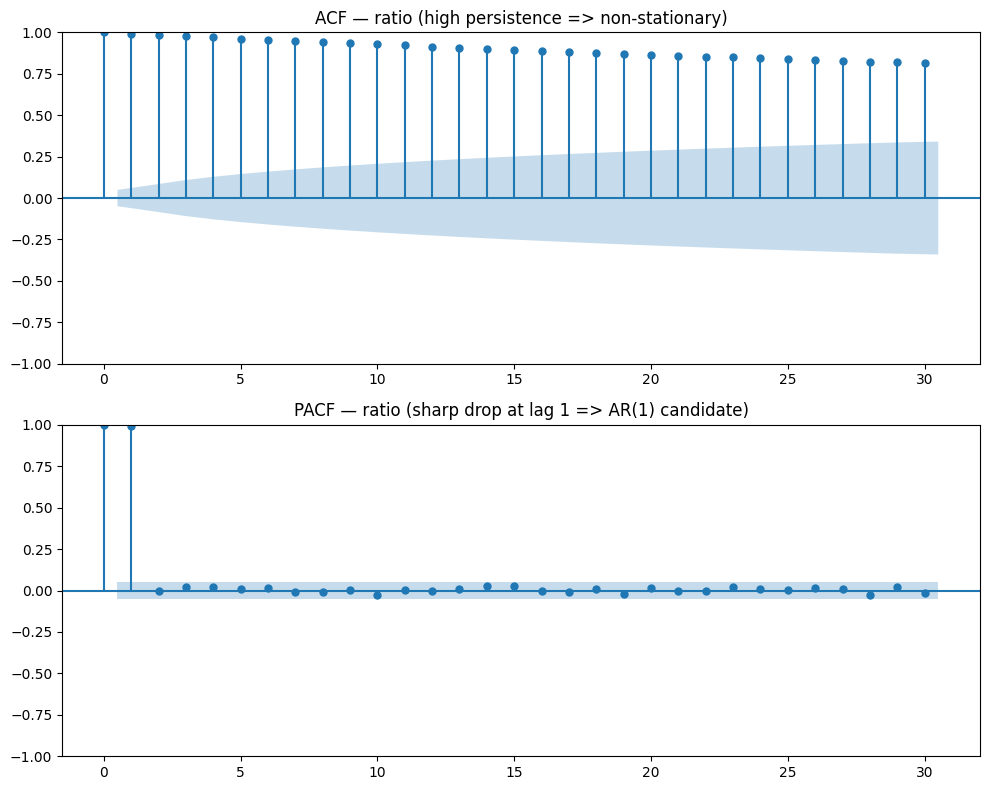

In [50]:
def check_stationarity(series, label="series"):
    """ADF test: p < 0.05 => reject H0 => stationary."""
    result = adfuller(series.dropna())
    print(f"--- {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("Summary: stationary (reject H0)\n")
    else:
        print("Summary: non-stationary (fail to reject H0)\n")


# Ratio in levels (expected non-stationary)
check_stationarity(data["ratio"], label="ratio (levels)")

# Log-diff: ln(ratio_t) - ln(ratio_{t-1})
data["log_price"] = np.log(data["ratio"])
data["log_diff"] = data["log_price"].diff()
check_stationarity(data["log_diff"], label="log-diff of ratio")

# ACF / PACF on ratio (persistence diagnostic)
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
tsaplots.plot_acf(data["ratio"].dropna(), ax=ax[0], lags=30)
ax[0].set_title("ACF — ratio (high persistence => non-stationary)")
tsaplots.plot_pacf(data["ratio"].dropna(), ax=ax[1], lags=30)
ax[1].set_title("PACF — ratio (sharp drop at lag 1 => AR(1) candidate)")
plt.tight_layout()
plt.show()

## Step 3: Cointegration Test

Run Engle–Granger `coint()` on **Adj Close** price levels (not on log-diff).  
**H0:** No cointegration  |  **p < 0.05** => reject H0; a long-run equilibrium relationship exists.

In [51]:
# Cointegration on adj close levels
score, pvalue, _ = coint(qqq_adj, voo_adj)
print(f"Cointegration test statistic: {score:.4f}")
print(f"Cointegration p-value: {pvalue:.4f}")
if pvalue < 0.05:
    print("Result: cointegrated (reject H0 at 5%)")
else:
    print("Result: NOT cointegrated (fail to reject H0 at 5%)")

Cointegration test statistic: -2.6670
Cointegration p-value: 0.2117
Result: NOT cointegrated (fail to reject H0 at 5%)


## Step 4: Conclusion

### Quantitative Summary

| Test | Result | Interpretation |
|------|--------|----------------|
| **Correlation** | QQQ and VOO Adj Close are highly positively correlated (typically > 0.95) | Long-run co-movement; start with visualization and correlation |
| **ADF — ratio** | p ≈ 0.10, **non-stationary** | Cannot apply mean-reversion ARMA directly to ratio levels |
| **ADF — log-diff** | p ≈ 0, **stationary** | Differenced ratio changes are usable for short-horizon dynamics |
| **Cointegration `coint()`** | p ≈ 0.21, **not cointegrated** | No stable long-run equilibrium; classical pairs assumption is weak |

### Trading and Modeling Implications

1. **Strong sync, weak cointegration:** High correlation does not imply tradable spread/ratio mean reversion. QQQ has structurally outperformed VOO since 2020, so the ratio trends rather than oscillates around a fixed mean.
2. **If trading the ratio:** Model on **log-diff or detrended stationary series**, with rolling windows, transaction costs, and position limits in backtests—not a static z-score alone.
3. **Pairs-trading viability:** At 5% significance we **fail to reject no cointegration**; in this sample **QQQ–VOO is not a strict cointegration pair**. Any live strategy should be framed as **relative-value / trending ratio**, not classic cointegration pairs.

> Re-run the cells above and update this table with the actual correlation and p-values from your run.